# Step 1 — Understand: What is Image Segmentation?

An image is basically a grid of pixels.  
Each pixel has an RGB value.

**The job of segmentation** = to divide those pixels into groups that belong to the same *object* or *region*.

---

## Example

If you take a photo of a park:

- 🟢 **Green pixels** → Grass / Trees  
- 🔵 **Blue pixels** → Sky  
- 🟤 **Brown pixels** → Path / Soil  

---

## Key Idea

Image Segmentation = grouping similar pixels together to identify meaningful parts of an image.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams['figure.dpi'] = 120
print("Libraries import done!")

Libraries import done!


C:\Users\Raghvendra Goyal\AppData\Local\Temp\ipykernel_10792\2341469367.py:29: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Raghvendra Goyal\AppData\Local\Temp\ipykernel_10792\2341469367.py:29: UserWarning: Glyph 11035 (\N{BLACK LARGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Raghvendra Goyal\AppData\Local\Temp\ipykernel_10792\2341469367.py:29: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


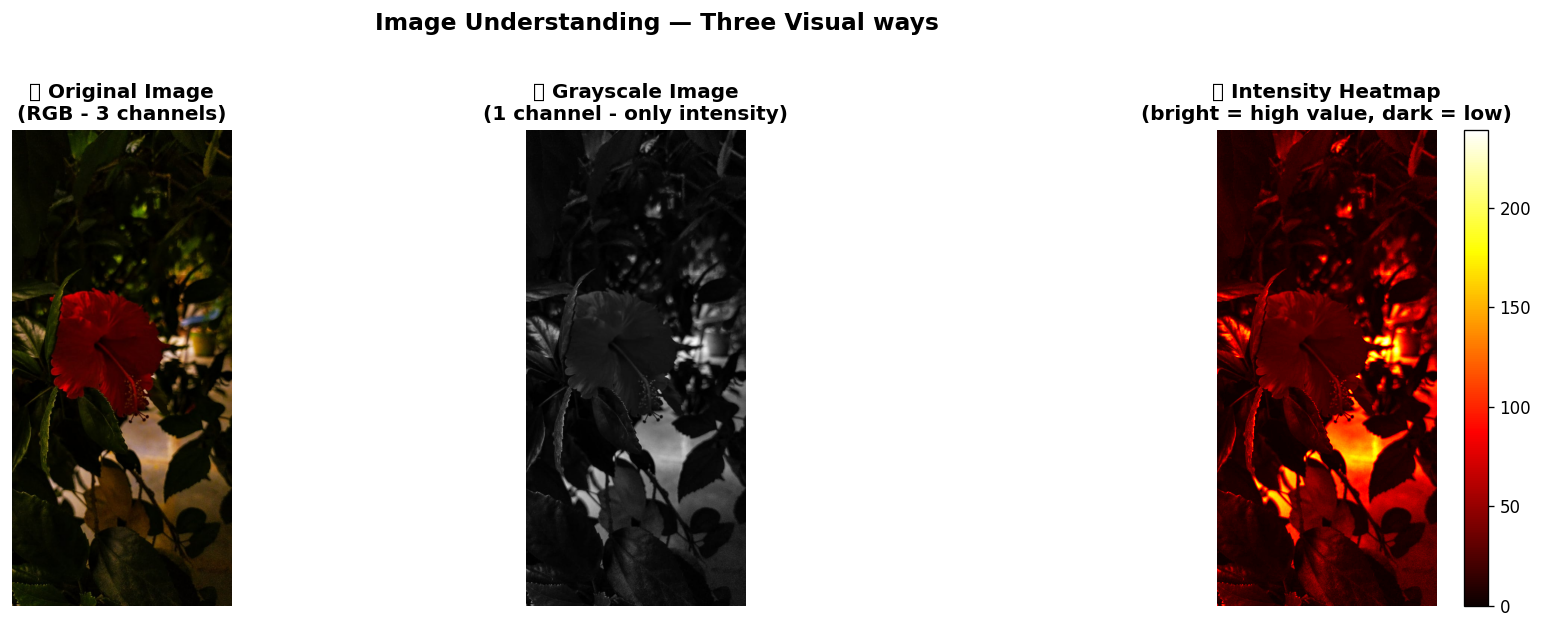

📐 Image Shape   : (1280, 590, 3)  →  (Height, Width, Channels)
🔢 Total Pixels  : 755,200
⬜ Gray Min Value: 0  (Total black)
⬛ Gray Max Value: 239  (Total white)
📊 Gray Mean     : 23.8  (Average brightness)


In [3]:
image_path = 'testimg.jpeg'   

# Loading image
img_bgr  = cv2.imread(image_path)
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# --- Comparison Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].imshow(img_rgb)
axes[0].set_title('🌈 Original Image\n(RGB - 3 channels)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Grayscale
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('⬛ Grayscale Image\n(1 channel - only intensity)', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Pixel Intensity Heatmap (visual explantion of grayscale)
im = axes[2].imshow(img_gray, cmap='hot')
axes[2].set_title('🌡️ Intensity Heatmap\n(bright = high value, dark = low)', fontsize=12, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle('Image Understanding — Three Visual ways', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Stats print 
print(f"📐 Image Shape   : {img_rgb.shape}  →  (Height, Width, Channels)")
print(f"🔢 Total Pixels  : {img_rgb.shape[0] * img_rgb.shape[1]:,}")
print(f"⬜ Gray Min Value: {img_gray.min()}  (Total black)")
print(f"⬛ Gray Max Value: {img_gray.max()}  (Total white)")
print(f"📊 Gray Mean     : {img_gray.mean():.1f}  (Average brightness)")

##  Step 3: Thresholding -> Foreground vs Background

**Idea:** Divide image into two parts — foreground (object) or background.

now check every pixel value:
- if pixel value > threshold → White (Foreground) 
- if pixel value < threshold → Black (Background) 

**Otsu's Method** this method automatically find best threshold value.

### Formula:
$$\sigma_B^2(t) = \omega_0(t) \cdot \omega_1(t) \cdot [\mu_0(t) - \mu_1(t)]^2$$

- $\omega_0, \omega_1$ = ratio of both classes pixels
- $\mu_0, \mu_1$ = avg. intensity of both classes
- $t$ = Threshold value (to be maximized)

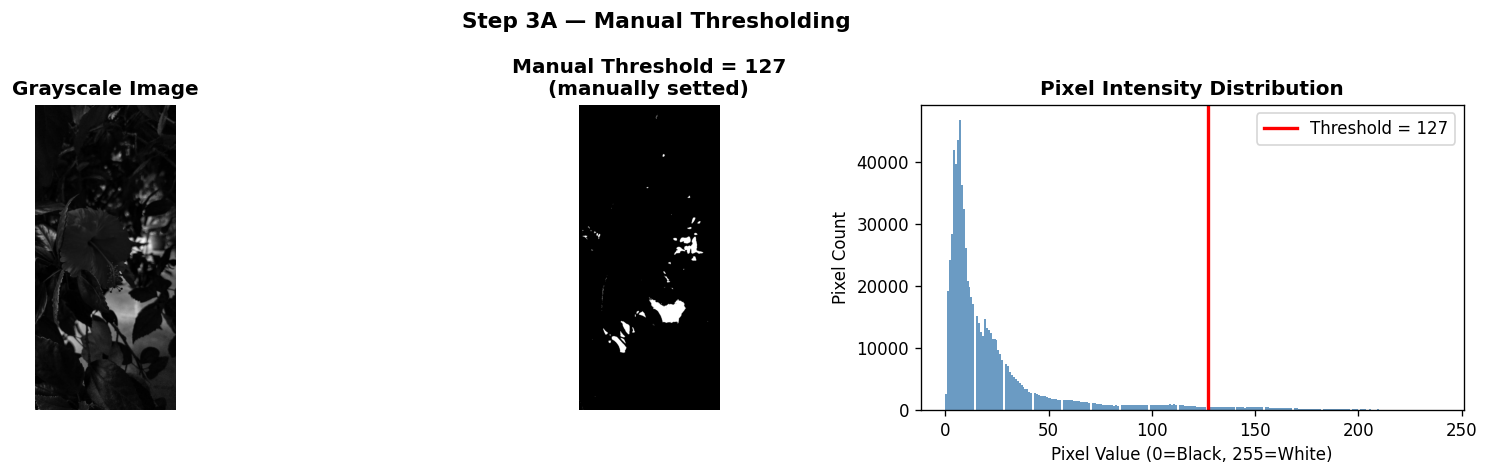

In [5]:
# Manual threshold 
manual_thresh = 127  # 0-255 mid vaalue between these two

_, manual_result = cv2.threshold(img_gray, manual_thresh, 255, cv2.THRESH_BINARY)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Grayscale Image', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(manual_result, cmap='gray')
axes[1].set_title(f'Manual Threshold = {manual_thresh}\n(manually setted)', fontweight='bold')
axes[1].axis('off')

# Histogram — samjho pixels kahan hain
axes[2].hist(img_gray.ravel(), bins=256, color='steelblue', alpha=0.8)
axes[2].axvline(manual_thresh, color='red', linewidth=2, 
                label=f'Threshold = {manual_thresh}')
axes[2].set_title('Pixel Intensity Distribution', fontweight='bold')
axes[2].set_xlabel('Pixel Value (0=Black, 255=White)')
axes[2].set_ylabel('Pixel Count')
axes[2].legend()

plt.suptitle('Step 3A — Manual Thresholding', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

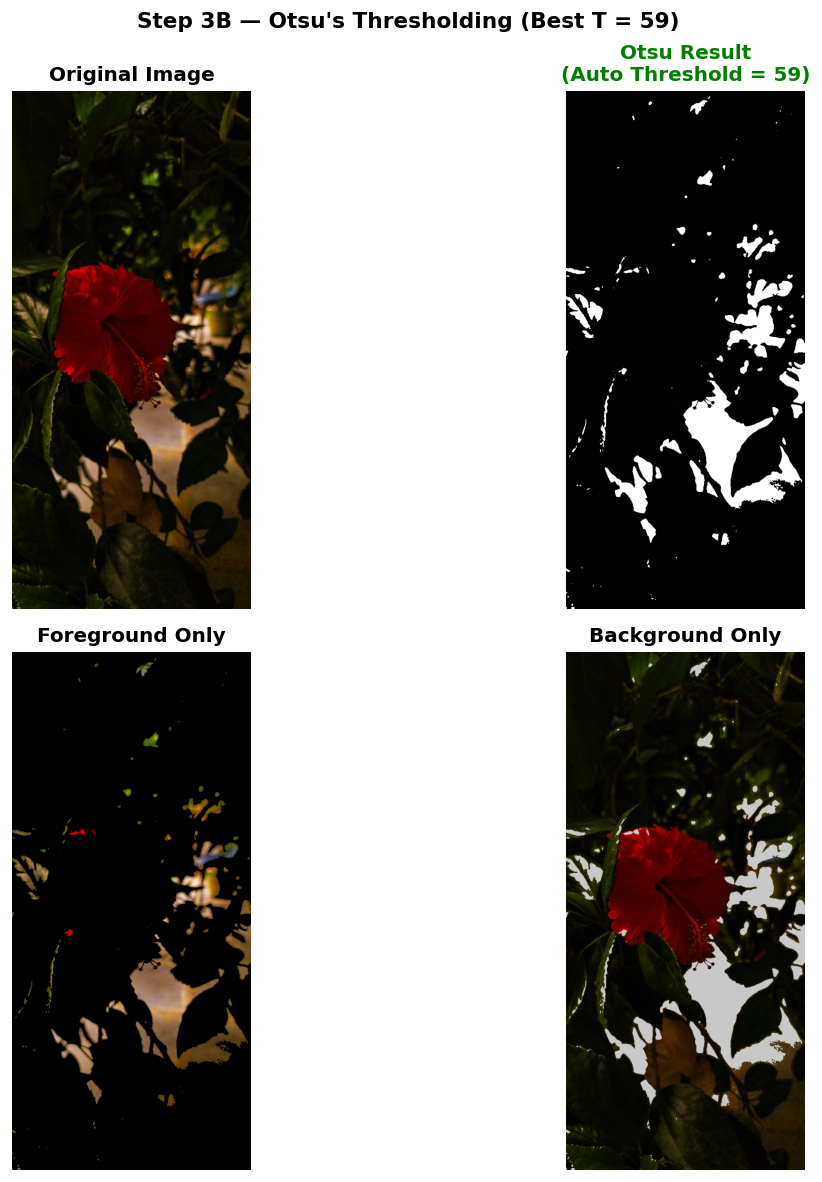

 Otsu best threshold: 59
 Foreground pixels: 72,515
 Background pixels: 682,685


In [6]:
# using Gaussian blur (to reducing noise)
blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

# otsu automatically find threshold
otsu_thresh, otsu_result = cv2.threshold(
    blurred, 0, 255, 
    cv2.THRESH_BINARY + cv2.THRESH_OTSU  
)

# Differenciate Foreground and Background (on Color image)
fg_image = img_rgb.copy()
bg_image = img_rgb.copy()

fg_mask = otsu_result == 255        # Foreground pixels
fg_image[~fg_mask] = [0, 0, 0]     # Background changed to black
bg_image[fg_mask]  = [200, 200, 200]  # Foreground changed to grey

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].imshow(img_rgb)
axes[0][0].set_title('Original Image', fontweight='bold')
axes[0][0].axis('off')

axes[0][1].imshow(otsu_result, cmap='gray')
axes[0][1].set_title(f'Otsu Result\n(Auto Threshold = {otsu_thresh:.0f})', 
                      fontweight='bold', color='green')
axes[0][1].axis('off')

axes[1][0].imshow(fg_image)
axes[1][0].set_title('Foreground Only', fontweight='bold')
axes[1][0].axis('off')

axes[1][1].imshow(bg_image)
axes[1][1].set_title('Background Only', fontweight='bold')
axes[1][1].axis('off')

plt.suptitle(f'Step 3B — Otsu\'s Thresholding (Best T = {otsu_thresh:.0f})', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f" Otsu best threshold: {otsu_thresh:.0f}")
print(f" Foreground pixels: {fg_mask.sum():,}")
print(f" Background pixels: {(~fg_mask).sum():,}")

## Step 4: Edge Detection

**What is Edge?**
Places where pixel values suddenly change, 
where one object vanish and new object start

### 2 Methods for thi:

| Method | How this work? |
|--------|----------------------|
| **Sobel** | it find gradient between X and Y direction. |
| **Canny** | Best edges, removes noise, and then detects edge |

### Sobel Formula:
$$G_x = \begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix} * I$$
$$G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ +1 & +2 & +1 \end{bmatrix} * I$$
$$G = \sqrt{G_x^2 + G_y^2}$$

- $I$ = Image matrix
- $G_x$ = Horizontal edges
- $G_y$ = Vertical edges
- $G$ = Final edge strength

C:\Users\Raghvendra Goyal\AppData\Local\Temp\ipykernel_10792\1361224808.py:31: UserWarning: Glyph 11035 (\N{BLACK LARGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Raghvendra Goyal\AppData\Local\Temp\ipykernel_10792\1361224808.py:31: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Raghvendra Goyal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


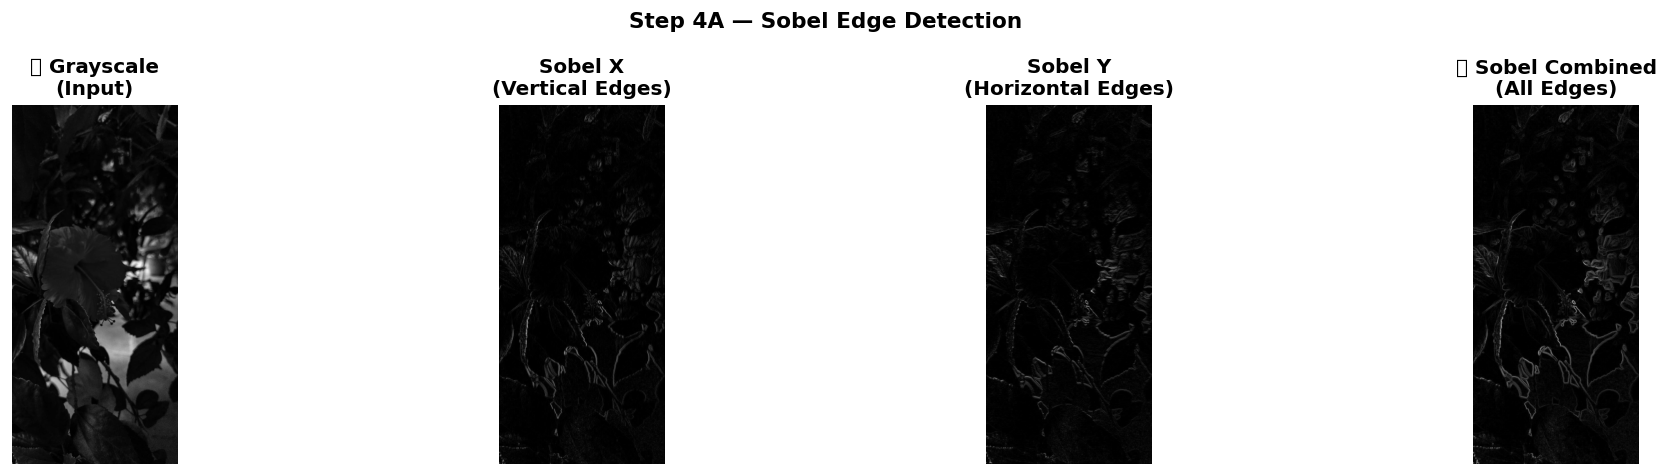

Edge pixels (>30): 45,315
Edge ratio: 6.0% of image


In [7]:
# Step 1: # Find Soble X and Y different different
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)  # Vertical edges
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)  # Horizontal edges

# Step 2: Combined magnitude → G = sqrt(Gx² + Gy²)
sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)

# Step 3: 0-255 normalize in this range
sobel_combined = np.uint8(sobel_combined / sobel_combined.max() * 255)

# Step 4: Plot 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('⬛ Grayscale\n(Input)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(np.abs(sobel_x), cmap='gray')
axes[1].set_title('Sobel X\n(Vertical Edges)', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(np.abs(sobel_y), cmap='gray')
axes[2].set_title('Sobel Y\n(Horizontal Edges)', fontweight='bold')
axes[2].axis('off')

axes[3].imshow(sobel_combined, cmap='gray')
axes[3].set_title('✨ Sobel Combined\n(All Edges)', fontweight='bold')
axes[3].axis('off')

plt.suptitle('Step 4A — Sobel Edge Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
edge_pixels = (sobel_combined > 30).sum()
total_pixels = img_gray.size
print(f"Edge pixels (>30): {edge_pixels:,}")
print(f"Edge ratio: {edge_pixels/total_pixels*100:.1f}% of image")

## Step 4B: Canny Edge Detection

Canny, Sobel se **smarter** hai — yeh 2 thresholds use karta hai:

| Threshold | Matlab |
|-----------|--------|
| **Lower** | no edges |
| **Upper** | there is a edge |
| **Beech mein** | only when where a edge is connected with different edge|

### Canny Pipeline:
$$\text{Image} \xrightarrow{\text{Blur}} \xrightarrow{\text{Gradient}} \xrightarrow{\text{Non-Max}} \xrightarrow{\text{Double Threshold}} \text{Edges}$$

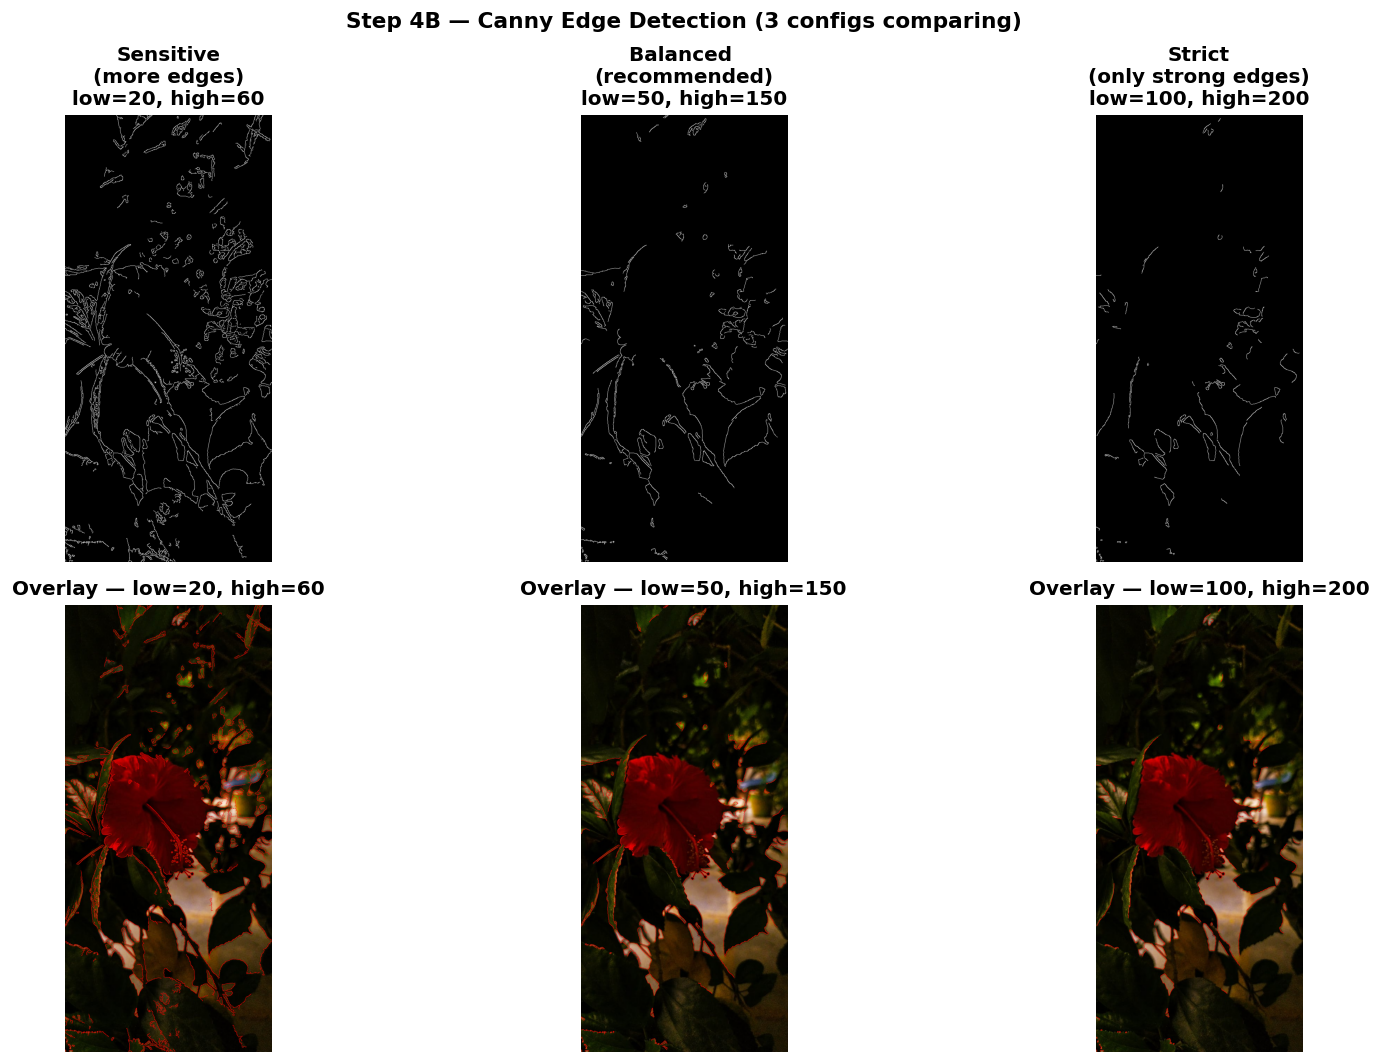

Best (Balanced) edge pixels : 11,004
Sobel edge pixels        : 45,315
Difference: Canny is more clean!


In [9]:
# try three different threshold combinations
configs = [
    (20, 60,  'Sensitive\n(more edges)'),
    (50, 150, 'Balanced \n(recommended)'),
    (100, 200, 'Strict\n(only strong edges)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for idx, (low, high, title) in enumerate(configs):
    edges = cv2.Canny(blurred, low, high)
    
    # Overlay the edges on original images (red color)
    overlay = img_rgb.copy()
    overlay[edges == 255] = [255, 0, 0]
    
    # Row 1: only edges
    axes[0][idx].imshow(edges, cmap='gray')
    axes[0][idx].set_title(f'{title}\nlow={low}, high={high}', fontweight='bold')
    axes[0][idx].axis('off')
    axes[0][idx].set_xlabel(f"Edges: {(edges==255).sum():,} pixels")
    
    # Row 2: Overlay on original
    axes[1][idx].imshow(overlay)
    axes[1][idx].set_title(f'Overlay — low={low}, high={high}', fontweight='bold')
    axes[1][idx].axis('off')

plt.suptitle('Step 4B — Canny Edge Detection (3 configs comparing)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Save the best results (Balanced)
best_edges = cv2.Canny(blurred, 50, 150)
print(f"Best (Balanced) edge pixels : {(best_edges==255).sum():,}")
print(f"Sobel edge pixels        : 45,315")
print(f"Difference: Canny is more clean!")

## 🎨 Step 5: K-Means Clustering Segmentation

**Idea:** Based on the RGB color of image pixels we divide them into K groups (clusters)

### Objective Function (To Minimize):
$$J = \sum_{j=1}^{K} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

- $K$ = how many segements want?
- $x_i$ = RGB value of individual pixel
- $\mu_j$ = Center of Cluster (mean color)
- $\|x_i - \mu_j\|^2$ = Distance between pixel and center

### Centroid Update Formula:
$$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$

In [11]:
from sklearn.cluster import KMeans

# Step 1: Convert the pixels of image into list
h, w, c = img_rgb.shape
pixels = img_rgb.reshape(-1, 3).astype(np.float32)
# Shape: (total_pixels, 3) → all pixels are a row [R, G, B]

print(f" Image shape     : {img_rgb.shape}")
print(f" Total pixels    : {pixels.shape[0]:,}")
print(f" Features per px : {pixels.shape[1]} (R, G, B)")

 Image shape     : (1280, 590, 3)
 Total pixels    : 755,200
 Features per px : 3 (R, G, B)


In [12]:
# Step 2: apply K-means
# K = 4 that means 4 segments/colors mein divide
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(pixels)

# here pixel get it's cluster number
labels = kmeans.labels_          # Shape: (total_pixels,)
centers = kmeans.cluster_centers_.astype(np.uint8)  # K colors

print(f" K-Means complete!")
print(f" Clusters making  : {K}")
print(f"\n mean color of every cluster (RGB):")
for i, color in enumerate(centers):
    print(f"   Cluster {i+1}: R={color[0]:3d}, G={color[1]:3d}, B={color[2]:3d}")

 K-Means complete!
 Clusters making  : 4

 mean color of every cluster (RGB):
   Cluster 1: R=107, G= 72, B= 29
   Cluster 2: R= 10, G= 10, B=  1
   Cluster 3: R= 58, G= 23, B=  4
   Cluster 4: R=172, G=130, B= 92


C:\Users\Raghvendra Goyal\AppData\Local\Temp\ipykernel_10792\3669473196.py:23: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Raghvendra Goyal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


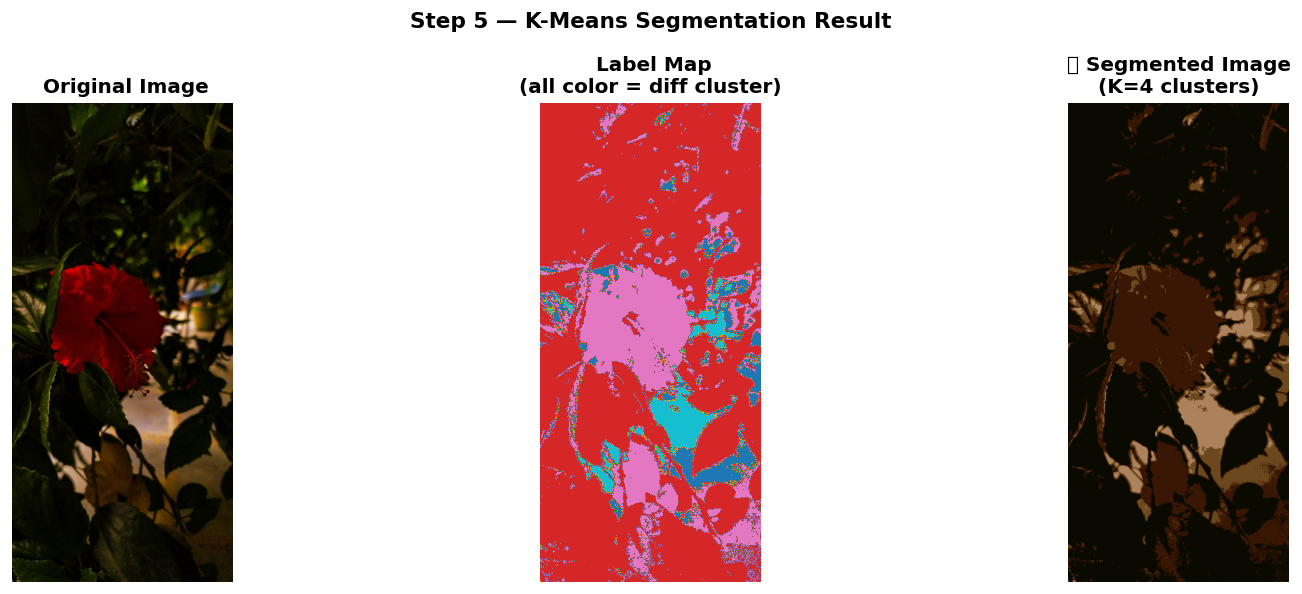

Cluster-wise pixel count:
   Cluster 1: 49,645 pixels (6.6%)
   Cluster 2: 512,121 pixels (67.8%)
   Cluster 3: 163,767 pixels (21.7%)
   Cluster 4: 29,667 pixels (3.9%)


In [13]:
# Step 3: make segmented image and visualize it

# give every pixel mean color to it's cluster
segmented_pixels = centers[labels]
segmented_image = segmented_pixels.reshape(h, w, 3)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title(' Original Image', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(labels.reshape(h, w), cmap='tab10')
axes[1].set_title(' Label Map\n(all color = diff cluster)', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(segmented_image)
axes[2].set_title(f'✨ Segmented Image\n(K={K} clusters)', fontweight='bold')
axes[2].axis('off')

plt.suptitle('Step 5 — K-Means Segmentation Result', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Har cluster mein kitne pixels hain
print("Cluster-wise pixel count:")
for i in range(K):
    count = (labels == i).sum()
    percent = count / len(labels) * 100
    print(f"   Cluster {i+1}: {count:,} pixels ({percent:.1f}%)")

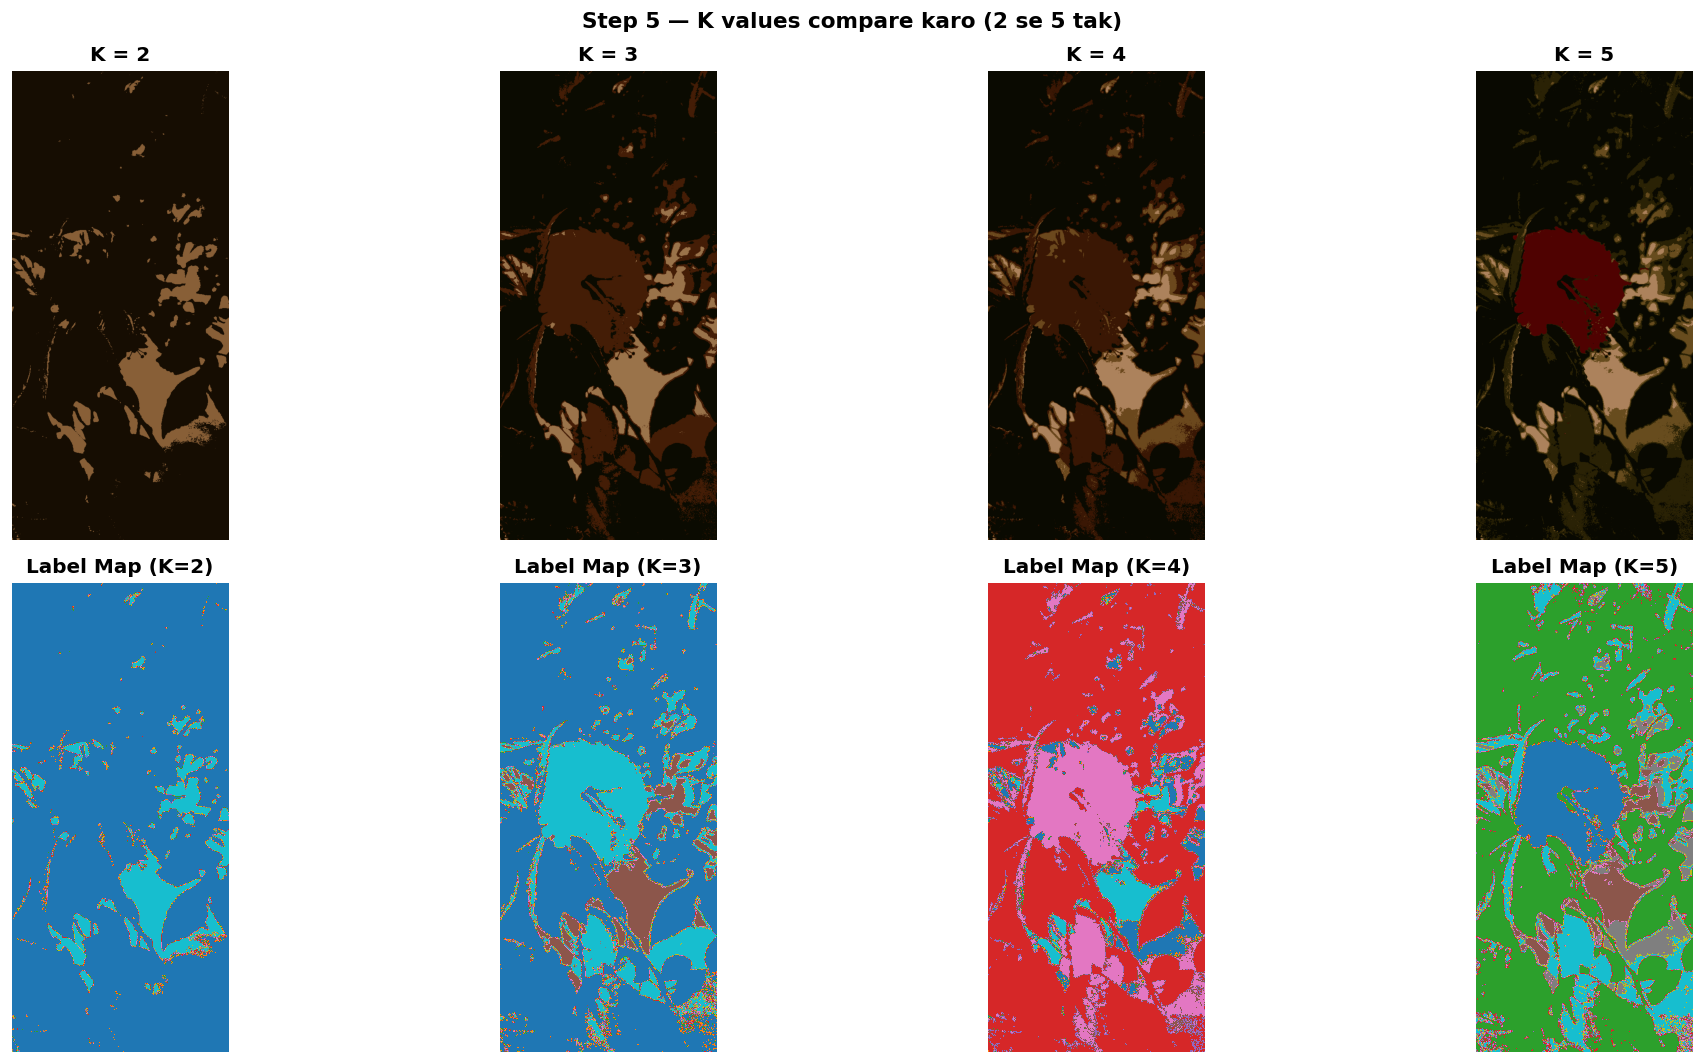

💡 Tip:
   K more = more detail = slow
   K less   = less detail  = fast

 Which K is best for my image?


In [14]:
# Step 4: K = 2, 3, 4, 5 compare karo — konsa best lagta hai?

K_values = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for idx, k in enumerate(K_values):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pixels)
    
    seg = km.cluster_centers_.astype(np.uint8)[km.labels_]
    seg_img = seg.reshape(h, w, 3)
    
    # Row 1: Segmented image
    axes[0][idx].imshow(seg_img)
    axes[0][idx].set_title(f'K = {k}', fontsize=12, fontweight='bold')
    axes[0][idx].axis('off')
    
    # Row 2: Label map
    axes[1][idx].imshow(km.labels_.reshape(h, w), cmap='tab10')
    axes[1][idx].set_title(f'Label Map (K={k})', fontsize=12, fontweight='bold')
    axes[1][idx].axis('off')

plt.suptitle('Step 5 — K values compare karo (2 se 5 tak)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Tip:")
print("   K more = more detail = slow")
print("   K less   = less detail  = fast")
print("\n Which K is best for my image?")

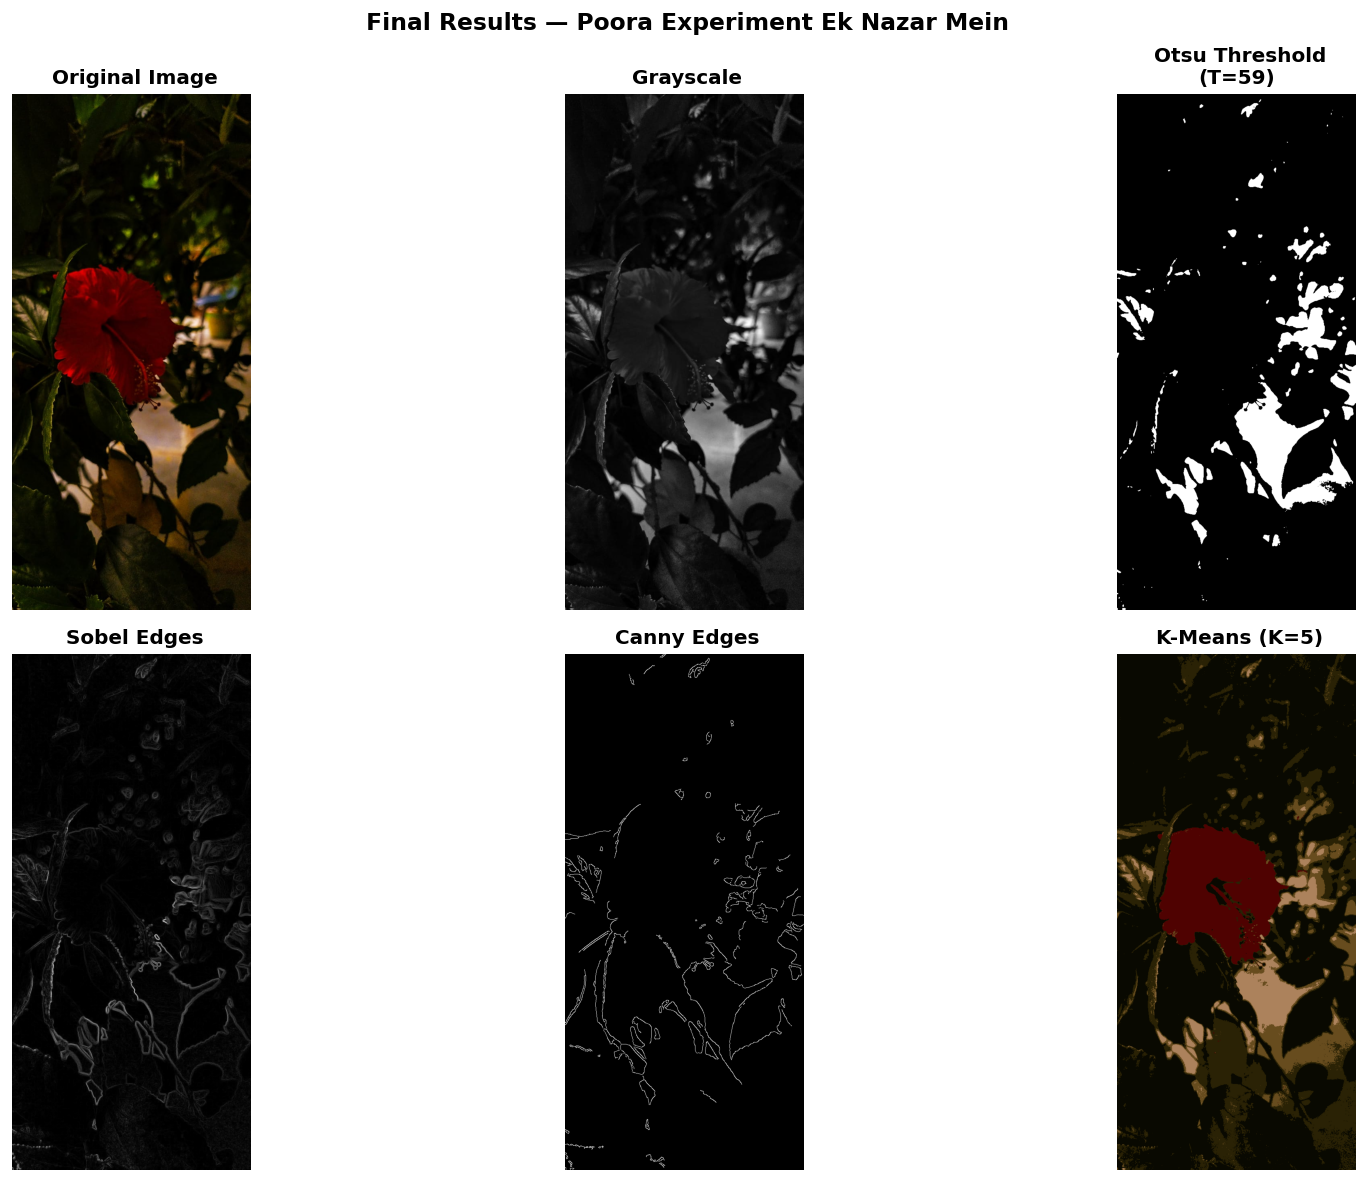

In [17]:
# CELL 6: Results + Conclusion

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Original
axes[0][0].imshow(img_rgb)
axes[0][0].set_title(' Original Image', fontweight='bold')
axes[0][0].axis('off')

# 2. Grayscale
axes[0][1].imshow(img_gray, cmap='gray')
axes[0][1].set_title(' Grayscale', fontweight='bold')
axes[0][1].axis('off')

# 3. Otsu Thresholding
axes[0][2].imshow(otsu_result, cmap='gray')
axes[0][2].set_title(f' Otsu Threshold\n(T={otsu_thresh:.0f})', fontweight='bold')
axes[0][2].axis('off')

# 4. Sobel Edges
axes[1][0].imshow(sobel_combined, cmap='gray')
axes[1][0].set_title(' Sobel Edges', fontweight='bold')
axes[1][0].axis('off')

# 5. Canny Edges
axes[1][1].imshow(best_edges, cmap='gray')
axes[1][1].set_title(' Canny Edges', fontweight='bold')
axes[1][1].axis('off')

# 6. K-Means Best Result
best_K = 5
km_final = KMeans(n_clusters=best_K, random_state=42, n_init=10)
km_final.fit(pixels)
seg_final = km_final.cluster_centers_.astype(np.uint8)[km_final.labels_]
seg_final = seg_final.reshape(h, w, 3)

axes[1][2].imshow(seg_final)
axes[1][2].set_title(f' K-Means (K={best_K})', fontweight='bold')
axes[1][2].axis('off')

plt.suptitle(' Final Results — Poora Experiment Ek Nazar Mein', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Conclusion Print karo


print("=" * 55)
print("         EXPERIMENT CONCLUSION")
print("=" * 55)

print(f"""
  Image Size     : {img_rgb.shape[0]} x {img_rgb.shape[1]} pixels
  Total Pixels   : {img_rgb.shape[0] * img_rgb.shape[1]:,}

 METHOD-WISE SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Otsu Thresholding
   → Best Threshold  : {otsu_thresh:.0f}
   → Foreground      : {(otsu_result==255).sum():,} pixels
   → Background      : {(otsu_result==0).sum():,} pixels

 Sobel Edge Detection
   → Edge Pixels     : {(sobel_combined > 30).sum():,}
   → Edge Ratio      : {(sobel_combined > 30).sum() / img_gray.size * 100:.1f}%

 Canny Edge Detection  
   → Edge Pixels     : {(best_edges==255).sum():,}
   → Thresholds Used : 50 (low), 150 (high)

 K-Means Clustering
   → Best K Value    : {best_K}
   → Segments Bane   : {best_K} color regions
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 CONCLUSION:
   Image segmentation se hum ek image ko meaningful
   regions mein divide kar sakte hain. Har method
   ka apna use case hai:
   
   • Thresholding → Simple, fast (binary only)
   • Edge Detection → Boundaries dhundne ke liye
   • K-Means → Color based segmentation best hai!
""")
print("=" * 55)
print(" Experiment Complete!")
print("=" * 55)

         EXPERIMENT CONCLUSION

  Image Size     : 1280 x 590 pixels
  Total Pixels   : 755,200

 METHOD-WISE SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Otsu Thresholding
   → Best Threshold  : 59
   → Foreground      : 72,515 pixels
   → Background      : 682,685 pixels

 Sobel Edge Detection
   → Edge Pixels     : 45,315
   → Edge Ratio      : 6.0%

 Canny Edge Detection  
   → Edge Pixels     : 11,004
   → Thresholds Used : 50 (low), 150 (high)

 K-Means Clustering
   → Best K Value    : 5
   → Segments Bane   : 5 color regions
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 CONCLUSION:
   Image segmentation se hum ek image ko meaningful
   regions mein divide kar sakte hain. Har method
   ka apna use case hai:

   • Thresholding → Simple, fast (binary only)
   • Edge Detection → Boundaries dhundne ke liye
   • K-Means → Color based segmentation best hai!

 Experiment Complete!
